In [2]:
import pandas as pd

In [4]:
import numpy as np

In [10]:
import matplotlib.pyplot as pyplot

In [12]:
import seaborn as sns

In [20]:
visa_df=pd.read_csv(r"C:\Users\kkali\Documents\NOTES\Visadataset.csv")

cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [22]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

**How to select the columns data**

In [28]:
visa_df.iloc[:,[1]]

,continent
0,Asia
1,Asia
2,Asia
3,Asia
4,Africa
...,...
25475,Asia
25476,Asia
25477,Asia
25478,Asia


In [32]:
visa_df.iloc[:,1]

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [34]:
visa_df.loc[:,'continent']

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [36]:
visa_df.loc[:,['continent']]

,continent
0,Asia
1,Asia
2,Asia
3,Asia
4,Africa
...,...
25475,Asia
25476,Asia
25477,Asia
25478,Asia


In [50]:
visa_df['continent']

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [46]:
visa_df['continent','case_status']   #series

KeyError: ('continent', 'case_status')

In [52]:
visa_df[['continent']]

,continent
0,Asia
1,Asia
2,Asia
3,Asia
4,Africa
...,...
25475,Asia
25476,Asia
25477,Asia
25478,Asia


In [48]:
visa_df[['continent','case_status']]   #dataframe

,continent,case_status
0,Asia,Denied
1,Asia,Certified
2,Asia,Denied
3,Asia,Denied
4,Africa,Certified
...,...,...
25475,Asia,Certified
25476,Asia,Certified
25477,Asia,Certified
25478,Asia,Certified


**How to convert into values**

In [55]:
visa_df['continent'].values

array(['Asia', 'Asia', 'Asia', ..., 'Asia', 'Asia', 'Asia'], dtype=object)

In [59]:
visa_df['continent'].values.ndim

1

In [57]:
visa_df[['continent']].values

array([['Asia'],
       ['Asia'],
       ['Asia'],
       ...,
       ['Asia'],
       ['Asia'],
       ['Asia']], dtype=object)

In [61]:
visa_df[['continent']].values.ndim

2

In [73]:
visa_df                                # Whole data
visa_df[['continent']]                 #specific column
visa_df[['continent']].values          # extract values from the columns
visa_df[['continent']].values[0]       # first value 
visa_df[['continent']].values[0][0]

'Asia'

**uniques-nunique**

In [80]:
visa_df['continent'].unique()

array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
       'Oceania'], dtype=object)

In [82]:
visa_df['continent'].nunique()

6

In [84]:
len(visa_df)

25480

- total 25480 applications from 6 continents

**Freequency tables**

- How many applications are there from asia

In [89]:
con=visa_df['continent']=='Asia'
# Access true values
len(visa_df[con])

16861

In [91]:
cond=visa_df['continent']=='Europe'
len(visa_df[cond])

3732

**Method-1**

In [131]:
count=[]
lables=visa_df['continent'].unique()
for i in lables:
    cond=visa_df['continent']==i
    values=len(visa_df[cond])
    count.append(values)
lables,count

(array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
        'Oceania'], dtype=object),
 [16861, 551, 3292, 3732, 852, 192])

In [145]:
continent_df=pd.DataFrame(zip(lables,count),columns=['Continent','Frequency'])
continent_df

,Continent,Frequency
0,Asia,16861
1,Africa,551
2,North America,3292
3,Europe,3732
4,South America,852
5,Oceania,192


In [147]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

**Method-2**

In [155]:
continent_vc=visa_df['continent'].value_counts()
lables=continent_vc.keys()
count=continent_vc.values
continent_df=pd.DataFrame(zip(lables,count),columns=['Class','Frequency'])
continent_df                          

,Class,Frequency
0,Asia,16861
1,Europe,3732
2,North America,3292
3,South America,852
4,Africa,551
5,Oceania,192


In [157]:
continent_vc=visa_df['continent'].value_counts(normalize=True)
continent_vc*100

continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64

In [161]:
continent_vc=visa_df['continent'].value_counts()
continent_vc
#not seperating keys and values
pd.DataFrame(continent_vc)

,count
continent,
Asia,16861
Europe,3732
North America,3292
South America,852
Africa,551
Oceania,192


**Method-3**

In [166]:
continent_vc=visa_df['continent'].value_counts()
continent_vc
#not seperating keys and values
continent_df=pd.DataFrame(continent_vc).reset_index()
continent_df

,continent,count
0,Asia,16861
1,Europe,3732
2,North America,3292
3,South America,852
4,Africa,551
5,Oceania,192


**Bar chart**`

<BarContainer object of 6 artists>

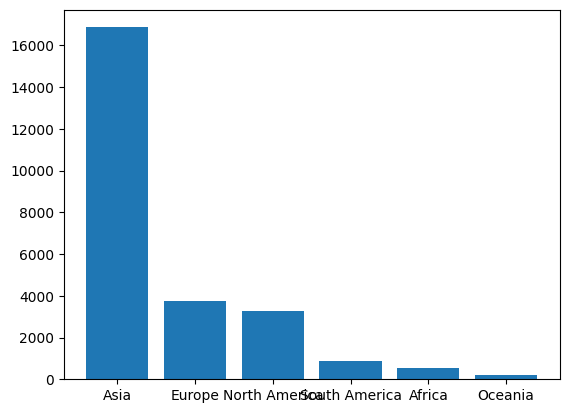

In [179]:
# frequency table name is continent_df
# classes column name : continent
# frequency column name: count
X_axis=visa_df['continent'].value_counts().keys()
Y_axis=visa_df['continent'].value_counts().values
pyplot.bar(X_axis,Y_axis)

<BarContainer object of 6 artists>

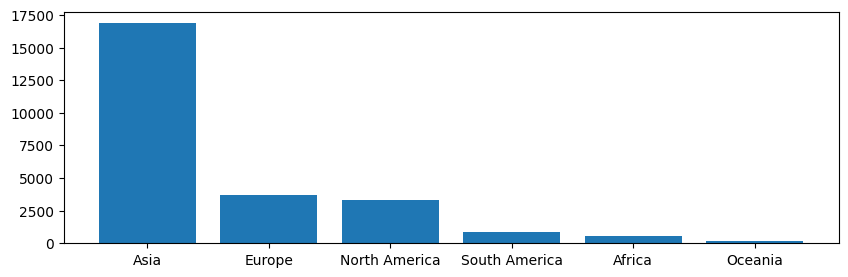

In [181]:
X_axis=visa_df['continent'].value_counts().keys()
Y_axis=visa_df['continent'].value_counts().values
pyplot.figure(figsize=(10,3))
pyplot.bar(X_axis,Y_axis)

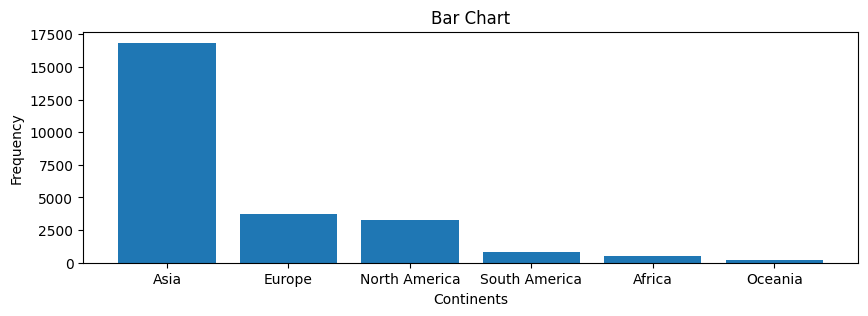

In [187]:
X_axis=visa_df['continent'].value_counts().keys()
Y_axis=visa_df['continent'].value_counts().values
pyplot.figure(figsize=(10,3))
pyplot.bar(X_axis,Y_axis)
pyplot.xlabel('Continents')
pyplot.ylabel('Frequency')
pyplot.title('Bar Chart')
pyplot.savefig('Continent_bar.jpg')
pyplot.show()

**Pie chart**

In [198]:
continent_vc=visa_df['continent'].value_counts(normalize=True)
continent_vc*100

continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64

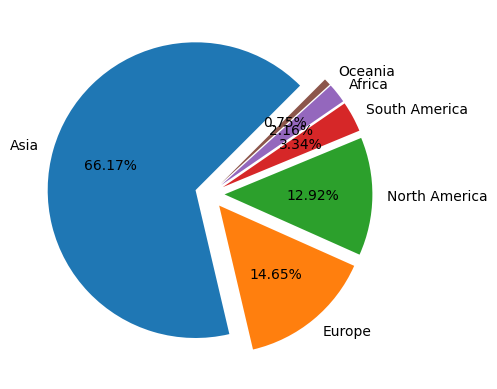

In [212]:
keys=visa_df['continent'].value_counts().keys()          #labels
values=visa_df['continent'].value_counts().values         # values
pyplot.pie(values,labels=keys,autopct='%0.2f%%',startangle=45,explode=[0.1,0.1,0.1,0.1,0.1,0.1])
pyplot.show()